## 1
¿Por qué una empresa podría no compartir sus datos reales?
## 2
¿Qué sesgos existen al utilizar información personal de clientes?
## 3
¿Crees que es posible entrenar un modelo de ML sin utilizar datos reales?

In [1]:
from faker import Faker

In [2]:
import pandas as pd 
import random

In [3]:
fake = Faker("es_MX")

In [27]:
datos = []
for i in range(1000):
    datos.append({
    "id_usuario": i +1,
    "nombre": fake.name(),
    "correo": fake.email(),
    "edad": random.randint(18,65),
    "seguidores": random.randint(100, 50000),
    "plataforma": random.choice(
        ["Tiktok", "Instagram", "YouTube"]
    )
})

In [29]:
# importar el dataset
df = pd.DataFrame(datos)

In [30]:
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Lucas Daniel Rodrígez Valverde,nluevano@example.net,30,44927,Instagram
1,2,Zeferino Aldo Godínez,ibarraenrique@example.net,23,35275,Instagram
2,3,Ing. Natividad Gurule,uriel30@example.net,62,2063,Tiktok
3,4,Silvia Casas,godinezmartin@example.net,41,19297,YouTube
4,5,Armando Mendoza Godínez,esteban89@example.org,48,16362,YouTube


In [31]:
#Exploración del Dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_usuario  1000 non-null   int64
 1   nombre      1000 non-null   str  
 2   correo      1000 non-null   str  
 3   edad        1000 non-null   int64
 4   seguidores  1000 non-null   int64
 5   plataforma  1000 non-null   str  
dtypes: int64(3), str(3)
memory usage: 47.0 KB


In [32]:
# Estadística descriptiva
df.describe(include = "all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.000000,1000,1000,1000.000000,1000.000000,1000
unique,NaN,1000,998,NaN,NaN,3
top,NaN,Lucas Daniel Rodrígez Valverde,lflorez@example.org,NaN,NaN,Instagram
freq,NaN,1,2,NaN,NaN,343
mean,500.500000,NaN,NaN,41.533000,24437.726000,NaN
std,288.819436,NaN,NaN,13.555466,14745.662984,NaN
min,1.000000,NaN,NaN,18.000000,120.000000,NaN
25%,250.750000,NaN,NaN,30.000000,11056.750000,NaN
50%,500.500000,NaN,NaN,42.000000,24309.500000,NaN
75%,750.250000,NaN,NaN,54.000000,37022.000000,NaN


In [33]:
# Importar las librerias para generar las graficas
import seaborn as sns
import matplotlib.pyplot as plt

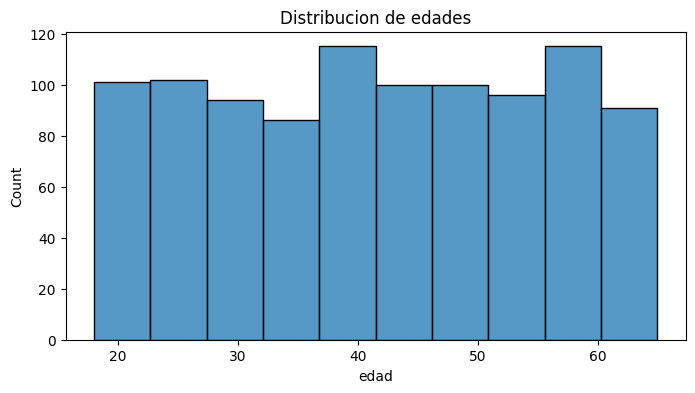

In [34]:
# Distribución de edades
plt.figure(figsize = (8, 4))
sns.histplot(
    df["edad"],
    bins = 10
)
plt.title("Distribucion de edades")
plt.show()

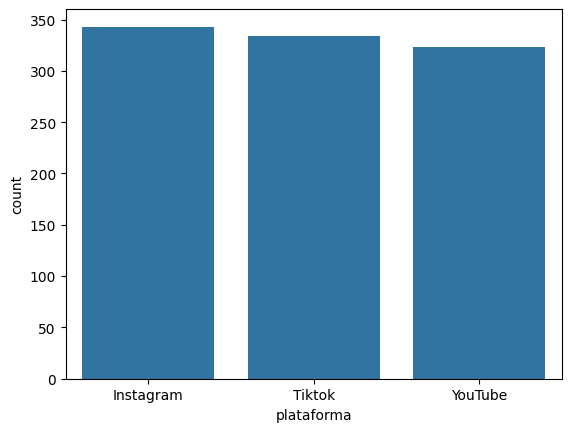

In [35]:
# Usuarios por plataforma
sns.countplot(
    x = "plataforma",
    data = df
)
plt.show()

In [36]:
# Generar una copia para contaminarla 
dfDirty = df.copy()

In [37]:
# Colocar valores nulos
for i in random.sample(range(len(dfDirty)), 5):
    dfDirty.loc[i, "nombre"] = None

In [38]:
dfDirty.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_usuario  1000 non-null   int64
 1   nombre      995 non-null    str  
 2   correo      1000 non-null   str  
 3   edad        1000 non-null   int64
 4   seguidores  1000 non-null   int64
 5   plataforma  1000 non-null   str  
dtypes: int64(3), str(3)
memory usage: 47.0 KB


In [39]:
# Edades inválidas
for i in random.sample(range(len(dfDirty)), 5):
    dfDirty.loc[i, "edad"] = -10

In [40]:
dfDirty.describe()["edad"]

count    1000.0000
mean       41.2780
std        13.9777
min       -10.0000
25%        30.0000
50%        41.0000
75%        53.0000
max        65.0000
Name: edad, dtype: float64

In [41]:
for i in random.sample(range(len(dfDirty)), 5):
    dfDirty.loc[i, "seguidores"] = 5000000

In [42]:
dfDirty.describe()["seguidores"]

count    1.000000e+03
mean     4.928921e+04
std      3.514299e+05
min      1.200000e+02
25%      1.110050e+04
50%      2.455150e+04
75%      3.725425e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [43]:
# Generamos correos inválidos
for i in random.sample(range(len(dfDirty)), 5):
    dfDirty.loc[i, "correo"] = "correo_invalido"

In [44]:
dfDirty.describe(include =  ["str", "object"])

,nombre,correo,plataforma
count,995,1000,1000
unique,995,994,3
top,Lucas Daniel Rodrígez Valverde,correo_invalido,Instagram
freq,1,5,343


In [45]:
dfDirty.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [48]:
# Estadísticas
dfDirty.describe(include = "all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.00,995,1000,1000.00,1000.00,1000
unique,NaN,995,994,NaN,NaN,3
top,NaN,Lucas Daniel Rodrígez Valverde,correo_invalido,NaN,NaN,Instagram
freq,NaN,1,5,NaN,NaN,343
mean,500.50,NaN,NaN,41.28,49289.21,NaN
std,288.82,NaN,NaN,13.98,351429.89,NaN
min,1.00,NaN,NaN,-10.00,120.00,NaN
25%,250.75,NaN,NaN,30.00,11100.50,NaN
50%,500.50,NaN,NaN,41.00,24551.50,NaN
75%,750.25,NaN,NaN,53.00,37254.25,NaN


In [49]:
# eliminar potencias
pd.set_option("display.float_format", lambda x: "%.2f" % x)